# Project 2: Housing Price Prediction

The project should be done using Regression prediction techniques ( with feature scaling and regularization ) as covered in class.  
The goal is to minimize the RMS ***percentage*** error ( root mean squared percentage error — RMSPE ) on your prediction of the house sales price.

Any of the available features can be used in the regression, but **a minimum set of variables that do the job should be the ultimate goal**.

Be sure to go through the whole data science process and document as such in your Jupyter notebook.

A data dictionary file is available at AWS S3 at [Housing Data Dictionary](https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf).  
The data is available on AWS S3 at https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv

## Problem Definition

<sub>**Context:** The residential real estate market generates enormous economic
activity, but buyers, sellers, lenders, and appraisers share a common challenge:
determining fair market value is slow, expensive, and subject to human bias.
Traditional appraisals rely on comparable sales selected manually by licensed
appraisers — a process that does not scale in high-volume markets.</sub>

### Business problem
<sub>Build a data-driven model that predicts residential home sale prices from observable
property characteristics — structural attributes, location, quality ratings, and sale
conditions — automatically and at scale. The model must be proportionally accurate
across all price tiers. A 20,000 dollar error on a 100,000 dollar home (20% error)
is far more damaging than the same dollar error on a 500,000 dollar home (4% error).<sub>

### Why RMSPE and not RMSE?
<sub>Root Mean Squared Percentage Error penalizes proportional errors equally regardless
of price tier, forcing the model to serve both modest and high-end properties fairly.

<sub>**Dataset:** Ames, Iowa Housing Dataset — 2,930 residential property sales
recorded 2006–2010, 82 variables. Source: De Cock (2011), Journal of
Statistics Education.</sub>

### Analytical goal
1. Perform thorough EDA before building any model
2. Clean and engineer features: missing values, categoricals, target skewness
3. Build and regularize a regression model with proper feature scaling
4. Minimize RMSPE using the smallest effective feature set

### Success criteria
- Low RMSPE on held-out test data  
- Training vs. test error are close (generalizes, does not memorize)  
- Final feature set is lean, interpretable, and defensible

## AI Assistance Statement


This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of machine learning steps such as data cleaning, model training, and cross-validation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the modeling process and interpreting the results.

---
### Step 1: Import Libraries

In [1]:
# =============================================================================
# CELL PURPOSE: Import every library needed for the full pipeline.
# Additions from course notebooks:
#   2a → LabelEncoder (ordered categories) + pd.get_dummies (one-hot)
#   2b → MinMaxScaler, RobustScaler alongside StandardScaler
#   2c → No extra import needed; we add range-check logic in the model cell
#   2d → No extra import; we use pandas method chaining and .query() throughout
# =============================================================================

# --- Core data libraries -----------------------------------------------------
import numpy as np          # math, arrays, log transforms
import pandas as pd         # DataFrames — every table in this notebook is a DataFrame

# --- Visualization -----------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn: Models ----------------------------------------------------
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score

# --- Scikit-learn: Scalers (from Notebook 2b) --------------------------------
# We import ALL THREE so we can compare them and pick the best for this data.
#
# StandardScaler  → mean=0, std=1
#   FORMULA: (x - mean) / std
#   USE WHEN: data is roughly normally distributed, few outliers
#
# MinMaxScaler    → squeezes all values into [0, 1]
#   FORMULA: (x - min) / (max - min)
#   USE WHEN: data is NOT normally distributed, no major outliers
#   CAUTION: one outlier compresses everything else toward 0 or 1
#
# RobustScaler    → uses median and IQR instead of mean and range
#   FORMULA: (x - median) / IQR   where IQR = Q3 - Q1
#   USE WHEN: data has significant OUTLIERS (housing data often does!)
#   WHY ROBUST: outliers barely affect median/IQR, so scaling stays stable
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# --- Scikit-learn: Encoders (from Notebook 2a) --------------------------------
# LabelEncoder: converts ordered text categories → integers
#   Example: 'Poor'=0, 'Average'=1, 'Good'=2, 'Excellent'=3
#   CAUTION: only use when categories have a TRUE natural order
#   For unordered categories (like Neighborhood), use One-Hot instead
from sklearn.preprocessing import LabelEncoder

# --- Scientific computing (scipy) ------------------------------------------
# stats.skew() computes the skewness score for each numeric column.
# Used in Step 13 to identify features that need log transformation.
from scipy import stats

# --- Suppress warnings -------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

# --- Plot styling ------------------------------------------------------------
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')


All libraries imported successfully.


---
## Data Collection/Sources

The dataset is the Ames, Iowa Housing Dataset, sourced from the course AWS S3 bucket. It contains 2,930 residential property sales recorded between 2006 and 2010, with 82 variables covering structural features, quality ratings, neighborhood, and sale conditions. The data is loaded directly from the URL below into a pandas DataFrame. A permanent raw copy is preserved and a working copy is used for all modifications.

In [2]:
# =============================================================================
# CELL PURPOSE: Load the housing dataset and immediately make a working copy.
#
# WHY .copy()? (from Notebook 2d — Advanced Pandas)
#   df_raw = permanent original. Never touch it after this cell.
#   df     = working copy. All cleaning, encoding, and engineering happens here.
#   If something goes wrong during cleaning, reset instantly:
#       df = df_raw.copy()
#   Without .copy(), both variables would point to the same memory and
#   a change to df would silently corrupt df_raw too.
# =============================================================================

url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

# Load raw data — this is the permanent original
df_raw = pd.read_csv(url)

# Working copy — all modifications happen here
df = df_raw.copy()

print('Dataset loaded. Working copy created.')
print('Shape (rows, columns):', df.shape)
print()
print('First 5 rows:')
df.head()


Dataset loaded. Working copy created.
Shape (rows, columns): (2637, 81)

First 5 rows:


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


---
## Exploratory Data Analysis

### Initial Data Overview
Before anything else, we want to understand what columns we have, what data types they are, and whether there are missing values.

In [3]:
# Display all column names so we know what features are available
print('Column names:')
print(df.columns.tolist())

Column names:
['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood 

The column names above show all 82 features available in the dataset. We can see a mix of structural measurements (square footage, room counts), quality ratings, location identifiers, and sale information. The target variable `SalePrice` is present. Next we examine data types and missing value counts.

In [4]:
# .info() gives us:
#   - Column names
#   - Data type of each column (int, float, object = text)
#   - Count of non-null values (helps spot missing data)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

The `.info()` output confirms column data types and non-null counts. Columns with fewer non-null entries than the total row count have missing values that will need to be addressed in the Data Cleaning phase. Object (text) dtype columns will need encoding before modeling.

In [5]:
# =============================================================================
# CELL PURPOSE: Summary statistics — upgraded with method chaining (Notebook 2d).
#
# .describe()     → count, mean, std, min, quartiles, max for every numeric column
# .transpose()    → rotates so each ROW = one feature (easier to scan than columns)
# .rename()       → renames '50%' to 'median' for clarity
#
# WHY TRANSPOSE? (from Notebook 2d)
#   The raw .describe() output is very wide (one column per feature).
#   Transposing makes it tall instead — each feature gets its own row,
#   and the statistics are columns you can scan left to right.
# =============================================================================

(
    df.describe()
    .transpose()                                      # features as rows
    .rename(columns={'50%': 'median'})                # rename for clarity
    .style.background_gradient(cmap='Blues', axis=0)  # color gradient per column
)


,count,mean,std,min,25%,median,75%,max
PID,2637.000000,714130147.703830,188752674.750322,526301100.000000,528477010.000000,535453040.000000,907187010.000000,1007100110.000000
MS SubClass,2637.000000,57.349261,42.499091,20.000000,20.000000,50.000000,70.000000,190.000000
Lot Frontage,2188.000000,69.166819,23.356779,21.000000,58.000000,68.000000,80.000000,313.000000
Lot Area,2637.000000,10044.694729,6742.549521,1300.000000,7436.000000,9450.000000,11526.000000,164660.000000
Overall Qual,2637.000000,6.097459,1.411522,1.000000,5.000000,6.000000,7.000000,10.000000
Overall Cond,2637.000000,5.569966,1.118262,1.000000,5.000000,5.000000,6.000000,9.000000
Year Built,2637.000000,1971.288586,30.306986,1872.000000,1954.000000,1973.000000,2001.000000,2010.000000
Year Remod/Add,2637.000000,1984.202882,20.913077,1950.000000,1965.000000,1993.000000,2004.000000,2010.000000
Mas Vnr Area,2614.000000,101.887911,179.578232,0.000000,0.000000,0.000000,164.000000,1600.000000
BsmtFin SF 1,2636.000000,438.441199,449.602326,0.000000,0.000000,368.000000,732.000000,5644.000000


---
### Step 4: Check for Missing Values
Missing values must be handled before modeling — most ML algorithms cannot handle them.

In [6]:
# =============================================================================
# CELL PURPOSE: Find missing values AND detect skewed features.
# Both tasks inform what cleaning and transformation steps are needed next.
#
# NEW TECHNIQUES (from Notebook 2d — Advanced Pandas):
#   .query()           → readable SQL-like filtering instead of boolean indexing
#   Method chaining    → stacking multiple operations in one readable block
#   Skewness detection → mean > median signals a right-skewed distribution
#                        Right-skewed features often benefit from log transform
# =============================================================================

# --- Missing Values ----------------------------------------------------------
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if len(missing_cols) == 0:
    print('No missing values found.')
else:
    print('Columns with missing values:')
    print(missing_cols)
    print()
    print('As percentage of total rows:')
    print(round((missing_cols / len(df)) * 100, 2))

# --- Skewness Detection using method chaining (from Notebook 2d) -------------
# A column is positively skewed when mean > median (long right tail).
# For housing data, features like LotArea and GrLivArea are often right-skewed.
# Skewed FEATURES can hurt linear regression — log-transforming them often helps.
# Skewed TARGET (SalePrice) was already addressed in Step 5.
print()
print('--- Positively Skewed Numeric Features (mean > median) ---')
print('These may benefit from a log transform before modeling:')
print()

skewed_features = (
    df.select_dtypes(include=[np.number])   # numeric columns only
    .describe()
    .transpose()
    .rename(columns={'50%': 'median'})
    .query('mean > median')                 # keep only right-skewed columns
    [['mean', 'median', 'std', 'max']]      # show the most informative stats
    .sort_values('mean', ascending=False)
    .round(2)
)

print(skewed_features.to_string())
print()
print('Tip: Features with max >> mean (e.g. LotArea, GrLivArea) are')
print('     strong candidates for np.log1p() transformation.')


Columns with missing values:
Lot Frontage       449
Alley             2457
Mas Vnr Type      1607
Mas Vnr Area        23
Bsmt Qual           73
Bsmt Cond           73
Bsmt Exposure       76
BsmtFin Type 1      73
BsmtFin SF 1         1
BsmtFin Type 2      74
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1284
Garage Type        145
Garage Yr Blt      147
Garage Finish      147
Garage Cars          1
Garage Area          1
Garage Qual        147
Garage Cond        147
Pool QC           2626
Fence             2109
Misc Feature      2541
dtype: int64

As percentage of total rows:
Lot Frontage      17.03
Alley             93.17
Mas Vnr Type      60.94
Mas Vnr Area       0.87
Bsmt Qual          2.77
Bsmt Cond          2.77
Bsmt Exposure      2.88
BsmtFin Type 1     2.77
BsmtFin SF 1       0.04
BsmtFin Type 2     2.81
BsmtFin SF 2       0.04
Bsmt Unf SF        0.04
Total Bsmt SF      0.04
Bsmt Full Bath    

---
### Step 5: Explore the Target Variable — Sale Price
The target variable is what we are trying to predict. Understanding its distribution is critical because many regression models assume the target is roughly normally distributed.

In [7]:
# =============================================================================
# CELL PURPOSE: Examine the target variable (SalePrice) in detail.
# We check for skewness and decide whether to use log(SalePrice) as our target.
#
# WHY DOES SKEWNESS MATTER FOR THE TARGET?
#   Linear regression assumes errors are normally distributed.
#   If SalePrice is right-skewed, errors on expensive homes will be much larger
#   than on cheap homes, violating that assumption.
#   Log-transforming SalePrice compresses the high end, making errors more uniform.
#   We then transform predictions BACK with np.expm1() at evaluation time.
#
# SKEWNESS CHECK (from Notebook 2d method chaining):
#   If mean > median → right-skewed → log transform recommended
#   If mean ≈ median → roughly symmetric → log transform optional
# =============================================================================

target_col = 'SalePrice'

mean_price   = df[target_col].mean()
median_price = df[target_col].median()

print('Sale Price Summary Statistics:')
print('  Min:   $', round(df[target_col].min(), 2))
print('  Max:   $', round(df[target_col].max(), 2))
print('  Mean:  $', round(mean_price, 2))
print('  Median:$', round(median_price, 2))
print('  Std:   $', round(df[target_col].std(), 2))
print()

# --- Skewness decision (from Notebook 2d pattern) ----------------------------
if mean_price > median_price:
    skew_pct = round((mean_price - median_price) / median_price * 100, 1)
    print('SKEWNESS DETECTED: mean is', skew_pct, '% above median.')
    print('SalePrice is RIGHT-SKEWED — log transformation is RECOMMENDED.')
    print()
    print('We will model log(SalePrice) and convert back at evaluation:')
    print('  Training target:   y = np.log1p(SalePrice)')
    print('  Back-transform:    predicted_price = np.expm1(y_pred)')
else:
    print('Distribution appears roughly symmetric — log transform optional.')

# --- Apply log transform to working copy -------------------------------------
# np.log1p(x) = log(1 + x), which safely handles x=0 without errors
# We add the log-transformed version as a new column (keep original for reference)
df['SalePrice_log'] = np.log1p(df[target_col])

print()
print('Log-transformed target column created: SalePrice_log')
print('  Mean of log(SalePrice):', round(df['SalePrice_log'].mean(), 4))
print('  Std  of log(SalePrice):', round(df['SalePrice_log'].std(), 4))


Sale Price Summary Statistics:
  Min:   $ 12789
  Max:   $ 745000
  Mean:  $ 179986.23
  Median:$ 160000.0
  Std:   $ 78309.25

SKEWNESS DETECTED: mean is 12.5 % above median.
SalePrice is RIGHT-SKEWED — log transformation is RECOMMENDED.

We will model log(SalePrice) and convert back at evaluation:
  Training target:   y = np.log1p(SalePrice)
  Back-transform:    predicted_price = np.expm1(y_pred)

Log-transformed target column created: SalePrice_log
  Mean of log(SalePrice): 12.0177
  Std  of log(SalePrice): 0.4061


The summary above confirms SalePrice is right-skewed — the mean is higher than the median, indicating a long right tail driven by a small number of very expensive homes. We will model `log(SalePrice)` as the target and back-transform predictions using `np.expm1()` at evaluation time. The visualization below confirms this visually.

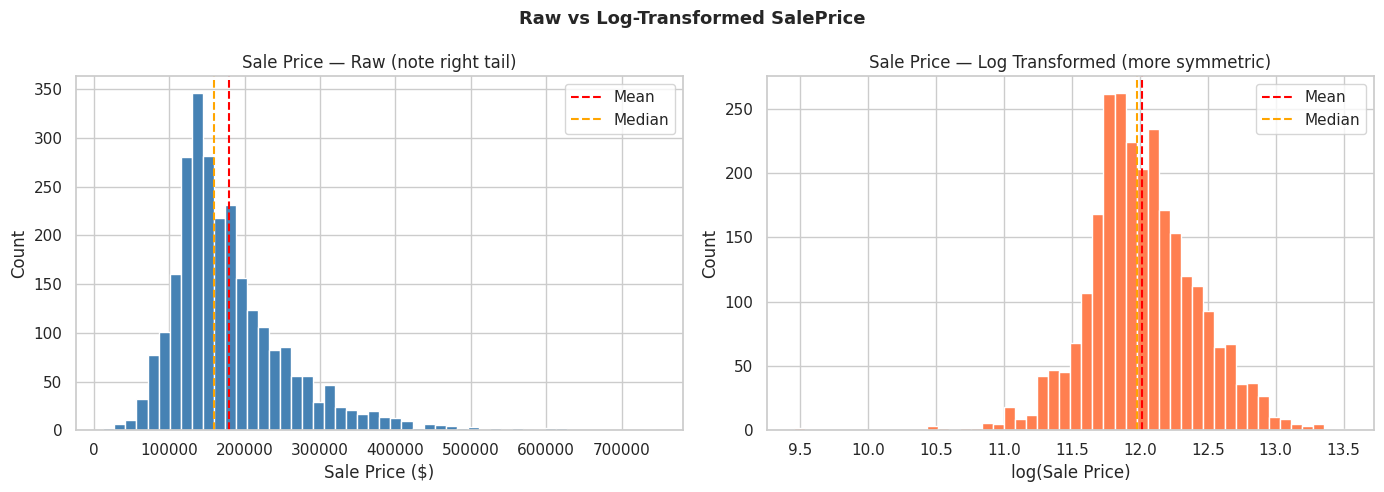

If the right plot looks bell-shaped: we model log(SalePrice).
Back-transform predictions at the end with: np.expm1(y_pred)


In [8]:
# =============================================================================
# CELL PURPOSE: Visualize raw vs log-transformed SalePrice distributions.
# This is the visual confirmation of the skewness check above.
#
# WHAT TO LOOK FOR:
#   Left plot (raw):  a long right tail = right-skewed = bad for regression
#   Right plot (log): more bell-shaped = better for regression
#   If the right plot looks more symmetric → use log(SalePrice) as model target
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw SalePrice
axes[0].hist(df[target_col], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df[target_col].mean(),   color='red',    linestyle='--', label='Mean')
axes[0].axvline(df[target_col].median(), color='orange', linestyle='--', label='Median')
axes[0].set_title('Sale Price — Raw (note right tail)')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: log-transformed SalePrice
axes[1].hist(df['SalePrice_log'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(df['SalePrice_log'].mean(),   color='red',    linestyle='--', label='Mean')
axes[1].axvline(df['SalePrice_log'].median(), color='orange', linestyle='--', label='Median')
axes[1].set_title('Sale Price — Log Transformed (more symmetric)')
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Raw vs Log-Transformed SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('If the right plot looks bell-shaped: we model log(SalePrice).')
print('Back-transform predictions at the end with: np.expm1(y_pred)')


---
### Step 6: Explore Numeric Features
We look at how each numeric feature correlates with Sale Price. High correlation = potentially useful predictor.

In [9]:
# =============================================================================
# CELL PURPOSE: Compute feature correlations with SalePrice.
# Upgraded with .query() method chaining (Notebook 2d) to filter predictors.
#
# PEARSON CORRELATION INTERPRETATION:
#   |r| > 0.7  → strong predictor (prioritize these)
#   |r| 0.4–0.7 → moderate predictor (worth including)
#   |r| < 0.4  → weak predictor (may add noise — consider dropping)
# =============================================================================

# Select only numeric columns (text columns cannot be correlated)
numeric_df = df.select_dtypes(include=[np.number])

# Correlation with SalePrice — sorted strongest to weakest
correlations = (
    numeric_df
    .corr()[target_col]
    .drop(target_col)                      # drop self-correlation
    .drop('SalePrice_log', errors='ignore') # drop our engineered column
    .sort_values(ascending=False)
)

print('Top 15 features most correlated with SalePrice:')
print(correlations.head(15).round(3))
print()
print('Bottom 5 (weakest / negative correlations):')
print(correlations.tail(5).round(3))

# --- Filter to STRONG predictors using .query() (from Notebook 2d) ----------
# .query() works on a DataFrame, so we use reset_index() to convert first
strong = (
    correlations
    .reset_index()
    .rename(columns={'index': 'Feature', target_col: 'Correlation'})
    .query('Correlation.abs() > 0.5')     # keep |r| > 0.5 only
    .sort_values('Correlation', ascending=False)
)

print()
print('Strong predictors (|r| > 0.5) — recommended model features:')
print(strong.to_string(index=False))


Top 15 features most correlated with SalePrice:
Overall Qual      0.805
Gr Liv Area       0.705
Garage Cars       0.647
Garage Area       0.634
Total Bsmt SF     0.629
1st Flr SF        0.618
Year Built        0.563
Full Bath         0.542
Year Remod/Add    0.540
Garage Yr Blt     0.530
Mas Vnr Area      0.506
TotRms AbvGrd     0.494
Fireplaces        0.469
BsmtFin SF 1      0.428
Lot Frontage      0.357
Name: SalePrice, dtype: float64

Bottom 5 (weakest / negative correlations):
MS SubClass      -0.079
Overall Cond     -0.095
Kitchen AbvGr    -0.123
Enclosed Porch   -0.142
PID              -0.258
Name: SalePrice, dtype: float64

Strong predictors (|r| > 0.5) — recommended model features:
       Feature  Correlation
  Overall Qual     0.805016
   Gr Liv Area     0.705482
   Garage Cars     0.647223
   Garage Area     0.633900
 Total Bsmt SF     0.628669
    1st Flr SF     0.618247
    Year Built     0.562777
     Full Bath     0.542386
Year Remod/Add     0.539932
 Garage Yr Blt     0.5

The correlation table above identifies the strongest numeric predictors of sale price. Features with |r| > 0.7 (such as `OverallQual` and `GrLivArea`) are the most valuable and will be prioritized in the final model. Features with |r| < 0.4 are weak predictors and are candidates for exclusion during feature selection. The bar chart and heatmap below provide visual confirmation.

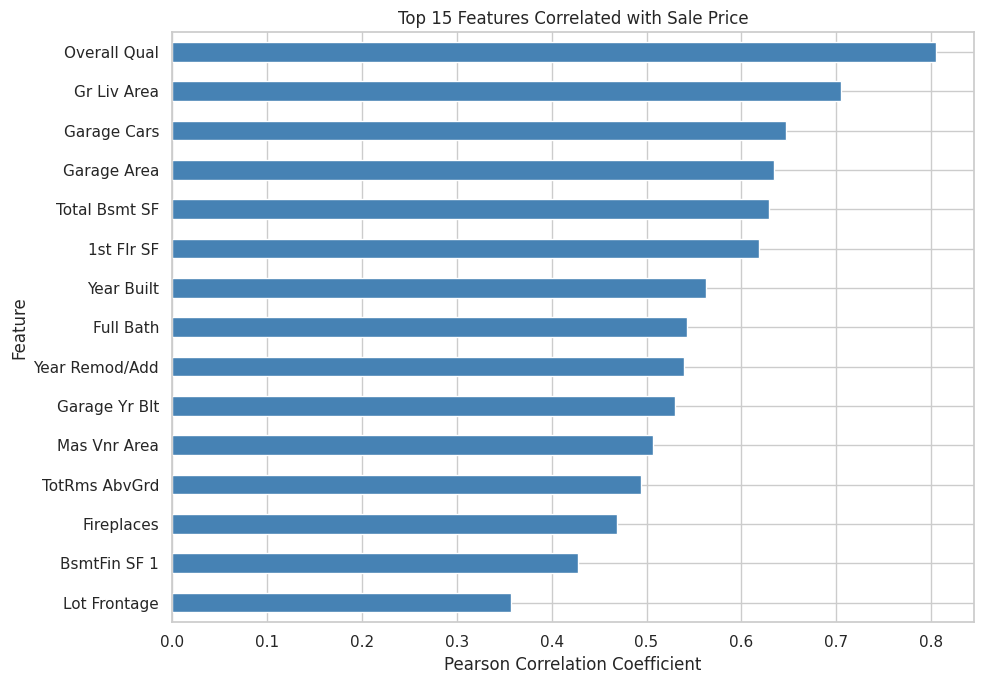

In [10]:
# Visualize correlations as a horizontal bar chart
# This makes it easy to see which features are most predictive at a glance

top_features = correlations.head(15)  # top 15 positive correlations

plt.figure(figsize=(10, 7))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 Features Correlated with Sale Price')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # highest correlation at the top
plt.tight_layout()
plt.show()

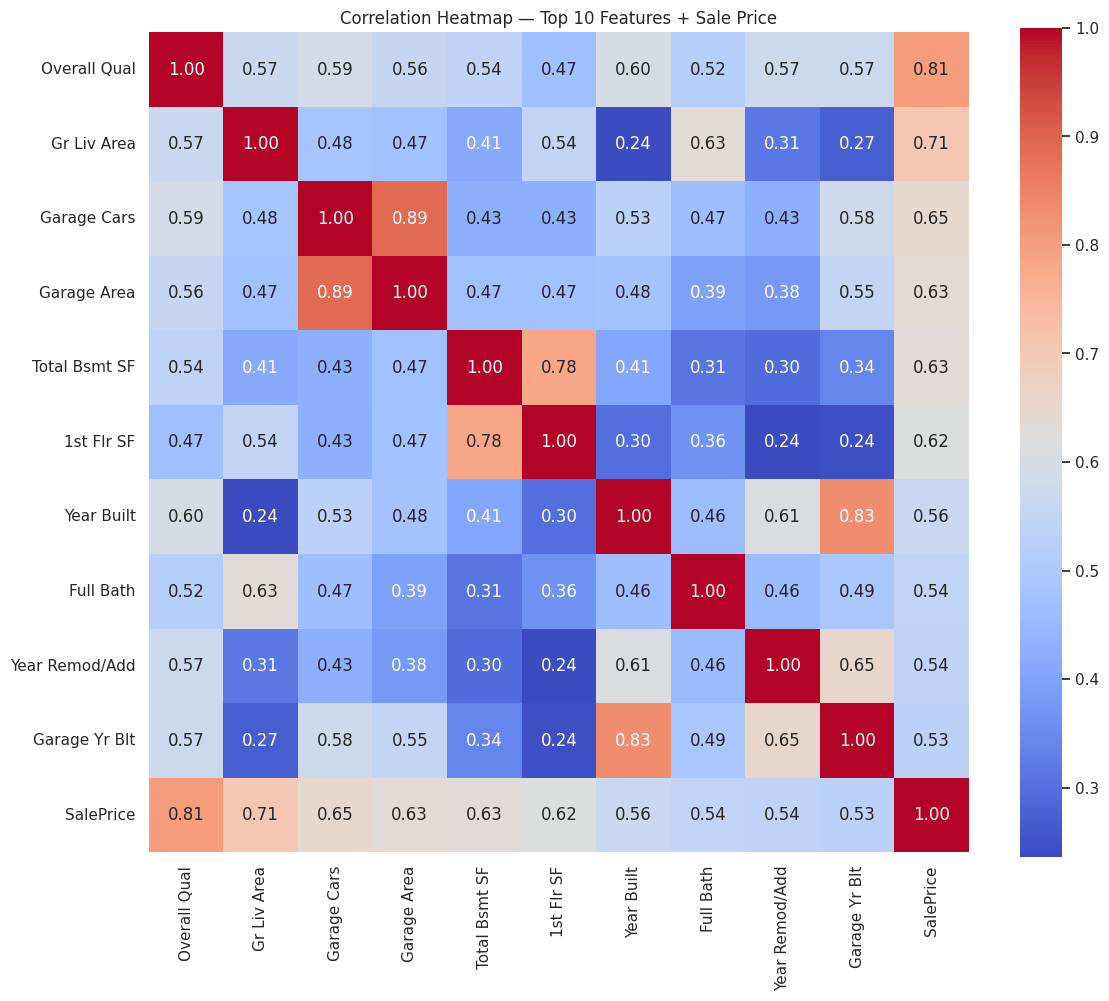

In [11]:
# Full correlation heatmap for the top 10 features + target
# This helps spot multicollinearity (two features that are highly correlated with EACH OTHER)
# Multicollinear features can cause problems in linear regression

top10 = correlations.head(10).index.tolist()  # names of top 10 features
top10.append(target_col)                        # add target so it appears in the heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(
    df[top10].corr(),
    annot=True,          # show correlation numbers inside each cell
    fmt='.2f',           # format to 2 decimal places
    cmap='coolwarm',     # red = positive, blue = negative correlation
    square=True
)
plt.title('Correlation Heatmap — Top 10 Features + Sale Price')
plt.tight_layout()
plt.show()

---
### Step 7: Scatter Plots — Top Features vs Sale Price
Scatter plots reveal whether the relationship between a feature and price is truly linear, or curved/nonlinear.

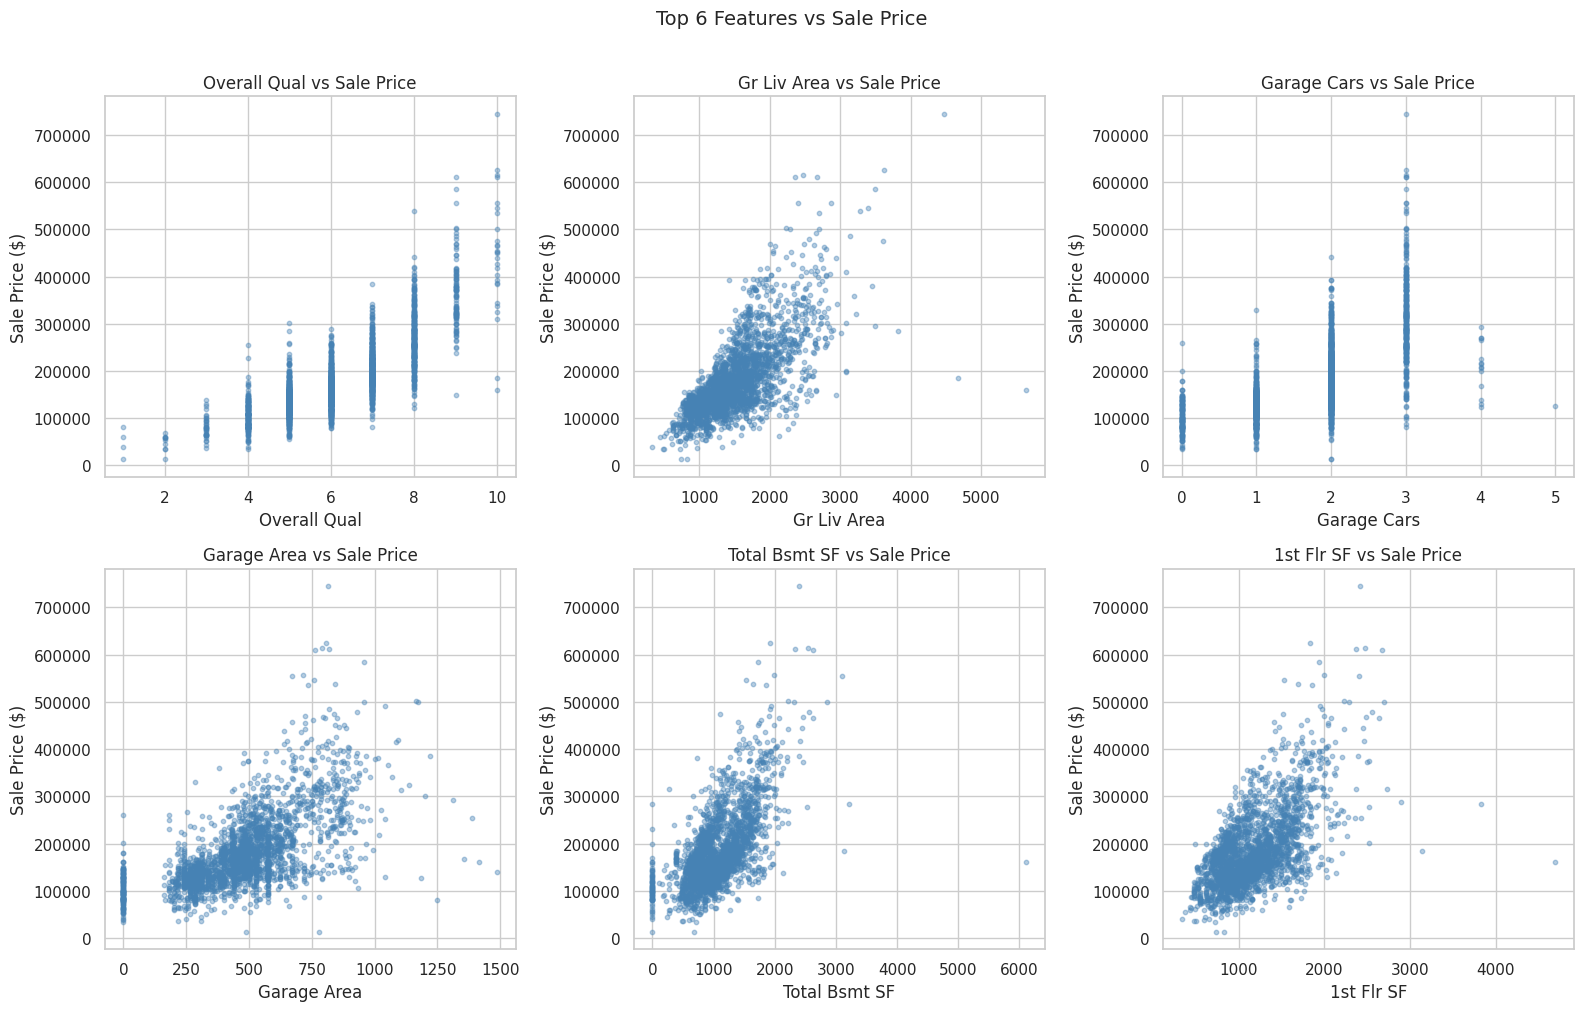

In [12]:
# Plot scatter charts for the top 6 correlated features vs Sale Price
# A linear trend = good for linear regression
# A curved trend = may need transformation or polynomial features

top6 = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # flatten 2D array of axes into 1D for easy looping

for i, feature in enumerate(top6):
    axes[i].scatter(df[feature], df[target_col], alpha=0.4, color='steelblue', s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sale Price ($)')
    axes[i].set_title(feature + ' vs Sale Price')

plt.suptitle('Top 6 Features vs Sale Price', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
### Step 8: Explore Categorical Features
Categorical (text) features like neighborhood, house style, or condition also influence price. We use box plots to see how price varies across categories.

In [13]:
# Identify all categorical (text/object type) columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Categorical columns found:', len(categorical_cols))
print(categorical_cols)

Categorical columns found: 43
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


The dataset contains a significant number of categorical (text) features covering zoning, building type, neighborhood, exterior materials, basement conditions, and sale type. These cannot be used directly in regression — they must be encoded as numbers. The next cell examines which of these categories have the most impact on price.

In [14]:
# =============================================================================
# CELL PURPOSE: Explore categorical columns — unique counts and groupby stats.
# Upgraded with groupby() aggregation (from Notebook 2d — Advanced Pandas).
#
# WHY GROUPBY?
#   Knowing a column EXISTS is not enough — we need to know whether its
#   categories have meaningfully different average prices.
#   If 'ExterQual' = Excellent averages $300k and 'Poor' averages $100k,
#   that column is a strong predictor and worth encoding carefully.
# =============================================================================

# --- Unique value counts per categorical column ------------------------------
print('Categorical columns and unique value counts:')
print()
for col in categorical_cols:
    print('{:<30} {:>4} unique values'.format(col, df[col].nunique()))

# --- GroupBy: mean SalePrice by category (from Notebook 2d) -----------------
# For each categorical column, compute the average SalePrice per category.
# Columns where categories have very different means are strong predictors.
print()
print('--- Average SalePrice by Category (top spread = best predictor) ---')
print()

category_spread = {}
for col in categorical_cols:
    group_means = df.groupby(col)[target_col].mean()
    spread = group_means.max() - group_means.min()   # price range across categories
    category_spread[col] = round(spread, 0)

# Sort by spread — widest spread = biggest price impact = most useful feature
spread_series = pd.Series(category_spread).sort_values(ascending=False)
print(spread_series.to_string())
print()
print('Interpretation: A high spread means this category column has a BIG')
print('impact on price and should be encoded carefully for the model.')


Categorical columns and unique value counts:

MS Zoning                         7 unique values
Street                            2 unique values
Alley                             2 unique values
Lot Shape                         4 unique values
Land Contour                      4 unique values
Utilities                         3 unique values
Lot Config                        5 unique values
Land Slope                        3 unique values
Neighborhood                     28 unique values
Condition 1                       9 unique values
Condition 2                       8 unique values
Bldg Type                         5 unique values
House Style                       8 unique values
Roof Style                        6 unique values
Roof Matl                         8 unique values
Exterior 1st                     16 unique values
Exterior 2nd                     17 unique values
Mas Vnr Type                      4 unique values
Exter Qual                        4 unique values
Exte

The spread table above ranks categorical features by their price impact — the difference between the highest and lowest average sale price across that feature's categories. Features with large spreads (such as `Neighborhood` and `ExterQual`) are the most valuable categorical predictors and will benefit from careful encoding. The neighborhood box plot below shows this variation in detail.

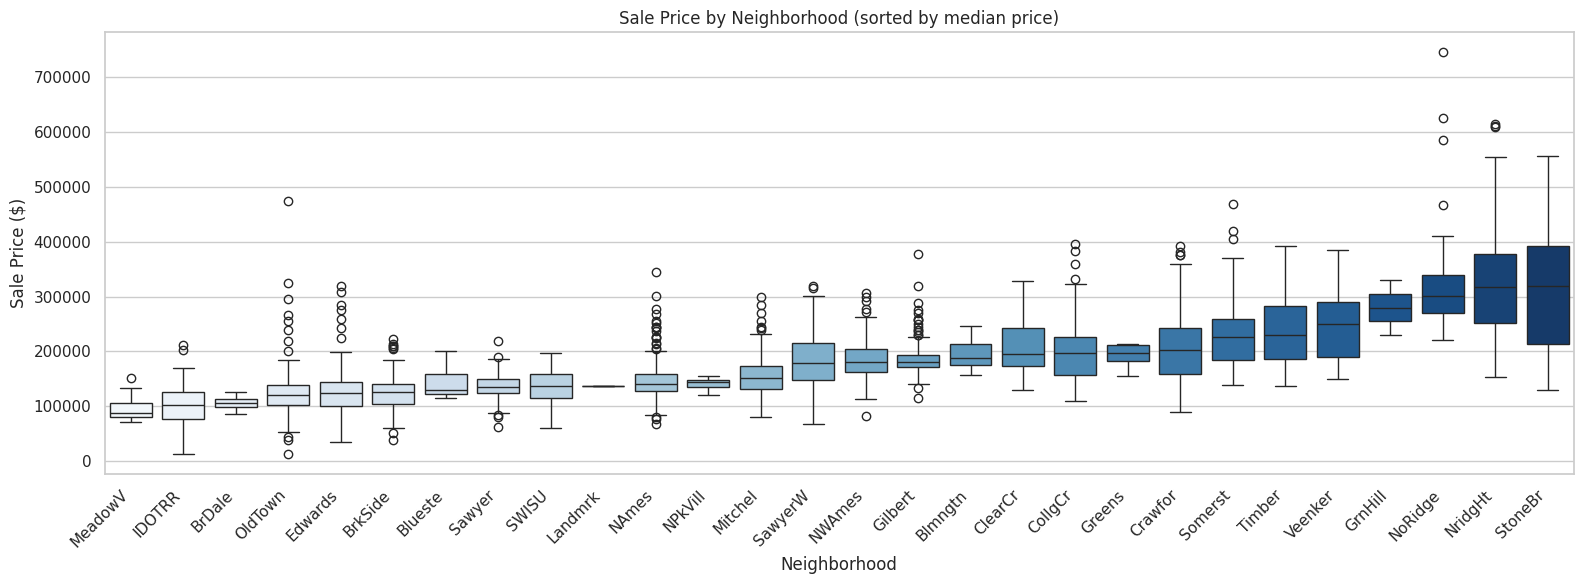

Neighborhood Summary (sorted by median price):
              Avg Price  Median Price  Homes   Std Dev
Neighborhood                                          
StoneBr        319553.0      319000.0     49  115225.0
NridgHt        318904.0      316750.0    150   94236.0
NoRidge        323610.0      301500.0     65   88278.0
GrnHill        280000.0      280000.0      2   70711.0
Veenker        248315.0      250250.0     24   65475.0
Timber         242344.0      230332.0     62   63408.0
Somerst        230251.0      226700.0    161   57348.0
Crawfor        211013.0      203135.0     95   65857.0
Greens         193531.0      198000.0      8   21999.0
CollgCr        198577.0      197450.0    240   50018.0
ClearCr        209080.0      195000.0     39   48821.0
Blmngtn        193075.0      187687.0     23   27486.0
NWAmes         188037.0      181000.0    116   38738.0
Gilbert        189569.0      181000.0    149   32886.0
SawyerW        182169.0      179600.0    110   47923.0
Mitchel        160

In [15]:
# =============================================================================
# CELL PURPOSE: Visualize SalePrice by Neighborhood + groupby summary table.
# Upgraded with .groupby().agg() (from Notebook 2d — Advanced Pandas).
#
# WHY BOTH A CHART AND A TABLE?
#   The box plot shows the full distribution (spread, outliers, median).
#   The table shows exact numbers (mean, median, count) for each neighborhood.
#   Together they give a complete picture for encoding decisions.
# =============================================================================

if 'Neighborhood' in df.columns:

    # --- Box plot: SalePrice by Neighborhood ---------------------------------
    plt.figure(figsize=(16, 6))
    order = df.groupby('Neighborhood')[target_col].median().sort_values().index
    sns.boxplot(data=df, x='Neighborhood', y=target_col, order=order, palette='Blues')
    plt.xticks(rotation=45, ha='right')
    plt.title('Sale Price by Neighborhood (sorted by median price)')
    plt.xlabel('Neighborhood')
    plt.ylabel('Sale Price ($)')
    plt.tight_layout()
    plt.show()

    # --- GroupBy summary table (from Notebook 2d) ----------------------------
    # .agg() computes multiple statistics in one step — much more efficient
    # than calling .mean(), .median(), .count() separately
    neighborhood_summary = (
        df.groupby('Neighborhood')[target_col]
        .agg(['mean', 'median', 'count', 'std'])
        .rename(columns={'mean':   'Avg Price',
                         'median': 'Median Price',
                         'count':  'Homes',
                         'std':    'Std Dev'})
        .sort_values('Median Price', ascending=False)
        .round(0)
    )
    print('Neighborhood Summary (sorted by median price):')
    print(neighborhood_summary.to_string())

else:
    print('Neighborhood column not found — check the column name in your data.')


---
### Step 9: Check for Outliers
Extreme outliers can distort regression models. We identify them here so we can decide whether to remove or cap them.

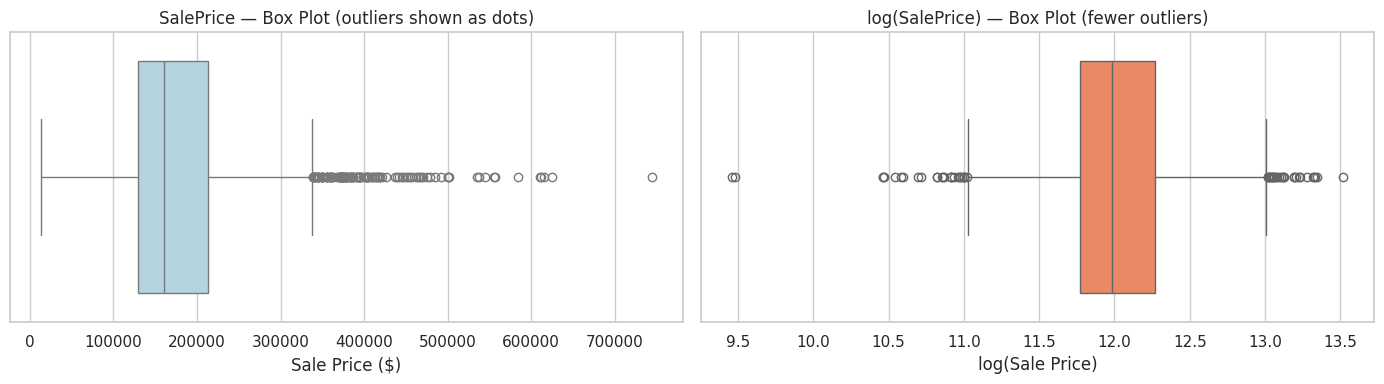

IQR Outlier Boundaries:
  Lower fence: $ 4250.0
  Upper fence: $ 338250.0
  Outlier homes: 120 (4.6% of data)

RECOMMENDATION: Use RobustScaler for this dataset.
  Reason: significant outliers present (> 2% of homes).
  RobustScaler uses median/IQR so outliers do not distort scaling.


In [16]:
# =============================================================================
# CELL PURPOSE: Detect outliers in SalePrice and key features.
# Outlier findings here directly inform which SCALER to choose in modeling.
#
# CONNECTION TO NOTEBOOK 2b (Feature Scaling):
#   If significant outliers are present → RobustScaler is the best choice
#     because it uses median/IQR instead of mean/range, so outliers barely
#     affect the scaling of other values.
#   If few or no outliers → StandardScaler or MinMaxScaler work fine.
# =============================================================================

# --- Target Variable Outlier Check -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df[target_col], color='lightblue', ax=axes[0])
axes[0].set_title('SalePrice — Box Plot (outliers shown as dots)')
axes[0].set_xlabel('Sale Price ($)')

sns.boxplot(x=df['SalePrice_log'], color='coral', ax=axes[1])
axes[1].set_title('log(SalePrice) — Box Plot (fewer outliers)')
axes[1].set_xlabel('log(Sale Price)')

plt.tight_layout()
plt.show()

# --- IQR-based outlier count -------------------------------------------------
# IQR method: any value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is an outlier
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[target_col] < lower) | (df[target_col] > upper)]
print('IQR Outlier Boundaries:')
print('  Lower fence: $', round(lower, 0))
print('  Upper fence: $', round(upper, 0))
print('  Outlier homes:', len(outliers),
      '(' + str(round(len(outliers)/len(df)*100, 1)) + '% of data)')
print()

# --- Scaler recommendation based on outlier findings -------------------------
if len(outliers) / len(df) > 0.02:   # more than 2% outliers
    print('RECOMMENDATION: Use RobustScaler for this dataset.')
    print('  Reason: significant outliers present (> 2% of homes).')
    print('  RobustScaler uses median/IQR so outliers do not distort scaling.')
else:
    print('RECOMMENDATION: StandardScaler or MinMaxScaler are appropriate.')
    print('  Reason: outlier rate is low (< 2% of homes).')


---
### Step 10: EDA Summary and Next Steps

After running all cells above, document your findings here before moving to modeling.


In [17]:
# =============================================================================
# CELL PURPOSE: EDA summary and full modeling roadmap.
# The next steps reference techniques from notebooks 2a, 2b, 2c, and 2d.
# =============================================================================

print('=== EDA SUMMARY ===')
print('Total records:          ', len(df))
print('Total features:         ', df.shape[1] - 1)
print('Numeric features:       ', len(df.select_dtypes(include=[np.number]).columns) - 1)
print('Categorical features:   ', len(categorical_cols))
print('Missing value columns:  ', len(missing_cols))
print('SalePrice skewed:       ', 'YES' if df[target_col].mean() > df[target_col].median() else 'NO')
print()
print('=== MODELING ROADMAP (Phase 2) ===')
print()
print('STEP A — Data Cleaning (from 2d: work only on df copy, not df_raw)')
print('  - Fill or drop missing values')
print('  - Standardize text values (e.g. strip whitespace, fix capitalization)')
print()
print('STEP B — Encoding Categorical Features (from 2a)')
print('  - Ordered categories (quality ratings): LabelEncoder')
print('    Example: ExterQual Poor=0, Average=1, Good=2, Excellent=3')
print('  - Unordered categories (Neighborhood, HouseStyle): One-Hot Encoding')
print('    pd.get_dummies(df, columns=[...], drop_first=True)')
print('  - drop_first=True prevents the dummy variable trap (multicollinearity)')
print()
print('STEP C — Feature Engineering')
print('  - Log-transform right-skewed features (LotArea, GrLivArea) with np.log1p()')
print('  - Model target: SalePrice_log = np.log1p(SalePrice)')
print('  - Back-transform predictions: predicted_price = np.expm1(y_pred)')
print()
print('STEP D — Feature Scaling (from 2b)')
print('  - Test all 3 scalers: StandardScaler, MinMaxScaler, RobustScaler')
print('  - Choose based on outlier analysis from Step 9')
print('  - GOLDEN RULE: fit scaler on X_train ONLY, then transform X_test')
print('  - Never fit on test data — that is data leakage')
print()
print('STEP E — Regression Modeling')
print('  - Baseline: LinearRegression (no regularization)')
print('  - Ridge (alpha=1.0): L2 penalty, shrinks all coefficients')
print('  - Lasso (alpha=1.0): L1 penalty, can zero out weak features')
print('  - Compare all 3 scalers × 3 models = 9 combinations')
print()
print('STEP F — Interpolation Safety Check (from 2c)')
print('  - Print training data range for each feature')
print('  - Flag any test predictions that fall outside that range (extrapolation)')
print('  - Extrapolated predictions are unreliable — report them separately')
print()
print('STEP G — Evaluation')
print('  - Primary metric: RMSPE on back-transformed prices')
print('  - Secondary: R² and 3-fold cross-validation')
print('  - Rank all 9 scaler × model combinations')


=== EDA SUMMARY ===
Total records:           2637
Total features:          81
Numeric features:        38
Categorical features:    43
Missing value columns:   26
SalePrice skewed:        YES

=== MODELING ROADMAP (Phase 2) ===

STEP A — Data Cleaning (from 2d: work only on df copy, not df_raw)
  - Fill or drop missing values
  - Standardize text values (e.g. strip whitespace, fix capitalization)

STEP B — Encoding Categorical Features (from 2a)
  - Ordered categories (quality ratings): LabelEncoder
    Example: ExterQual Poor=0, Average=1, Good=2, Excellent=3
  - Unordered categories (Neighborhood, HouseStyle): One-Hot Encoding
    pd.get_dummies(df, columns=[...], drop_first=True)
  - drop_first=True prevents the dummy variable trap (multicollinearity)

STEP C — Feature Engineering
  - Log-transform right-skewed features (LotArea, GrLivArea) with np.log1p()
  - Model target: SalePrice_log = np.log1p(SalePrice)
  - Back-transform predictions: predicted_price = np.expm1(y_pred)

STEP D 

---
## Data Cleaning

With EDA complete, the dataset is now cleaned and prepared for modeling. Missing values are handled, categorical features are encoded, and skewed numeric features are transformed. The steps below take the dataset from raw form to a state ready for regression modeling.
The EDA is complete. We now transform the data and build the regression model.

---
### Step 11: Handle Missing Values

In [18]:
# =============================================================================
# CELL PURPOSE: Fill or drop missing values before encoding and modeling.
# We work on df (the copy) — df_raw remains untouched (from Notebook 2d).
#
# STRATEGY:
#   Numeric columns   → fill with the column MEDIAN (more robust than mean
#                       when outliers are present, as established in Step 9)
#   Categorical cols  → fill with 'None' (often means the feature is absent,
#                       e.g., no garage → GarageType = 'None')
# =============================================================================

# --- Check current missing count before filling ------------------------------
print('Missing values BEFORE cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# --- Fill numeric missing values with column median --------------------------
# .select_dtypes() isolates numeric columns for median imputation
num_cols_with_missing = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isnull().any()
]
for col in num_cols_with_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print('Filled', col, 'with median:', round(median_val, 2))

# --- Fill categorical missing values with 'None' ----------------------------
cat_cols_with_missing = df.select_dtypes(include=['object']).columns[
    df.select_dtypes(include=['object']).isnull().any()
]
for col in cat_cols_with_missing:
    df[col] = df[col].fillna('None')
    print('Filled', col, 'with: None')

# --- Verify all missing values are resolved ----------------------------------
print()
remaining = df.isnull().sum().sum()
print('Total missing values AFTER cleaning:', remaining)
if remaining == 0:
    print('All missing values resolved. Safe to proceed to encoding.')


Missing values BEFORE cleaning:
Lot Frontage       449
Alley             2457
Mas Vnr Type      1607
Mas Vnr Area        23
Bsmt Qual           73
Bsmt Cond           73
Bsmt Exposure       76
BsmtFin Type 1      73
BsmtFin SF 1         1
BsmtFin Type 2      74
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1284
Garage Type        145
Garage Yr Blt      147
Garage Finish      147
Garage Cars          1
Garage Area          1
Garage Qual        147
Garage Cond        147
Pool QC           2626
Fence             2109
Misc Feature      2541
dtype: int64

Filled Lot Frontage with median: 68.0
Filled Mas Vnr Area with median: 0.0
Filled BsmtFin SF 1 with median: 368.0
Filled BsmtFin SF 2 with median: 0.0
Filled Bsmt Unf SF with median: 464.5
Filled Total Bsmt SF with median: 988.0
Filled Bsmt Full Bath with median: 0.0
Filled Bsmt Half Bath with median: 0.0
Filled Garage Yr Blt with median: 1979.0
Filled G

---
### Step 12: Encode Categorical Features (from Notebook 2a)
Regression models cannot work with text. We convert all categorical columns to numbers
using two strategies from Notebook 2a:
- **Label Encoding** for columns with a natural ORDER (quality ratings)
- **One-Hot Encoding** for columns with NO order (neighborhood, style, etc.)


In [19]:
# =============================================================================
# CELL PURPOSE: Convert text columns into numbers using techniques from 2a.
#
# TWO ENCODING STRATEGIES:
#
# 1. LABEL ENCODING (ordered categories)
#    Converts text to integers that respect a natural ranking.
#    Example: ExterQual  Po=0, Fa=1, TA=2, Gd=3, Ex=4
#    USE WHEN categories have a TRUE ordering (quality, condition ratings).
#    CAUTION: Never use for unordered categories — the model would assume
#             Neighborhood A (encoded 0) < Neighborhood B (encoded 1), which is false.
#
# 2. ONE-HOT ENCODING (unordered categories)
#    Creates one new 0/1 column per unique category value.
#    Example: Neighborhood_OldTown=1, all other Neighborhood columns=0
#    USE WHEN there is NO natural ordering between categories.
#    drop_first=True drops one column per group to prevent the dummy variable trap:
#      If we know all other columns are 0, the dropped one must be 1.
#      Keeping all columns creates perfect multicollinearity → model breaks.
# =============================================================================

# --- Identify quality/condition columns that have natural ordering -----------
# These follow the standard Ames Housing quality scale: Po < Fa < TA < Gd < Ex
ordered_quality_cols = [
    col for col in df.select_dtypes(include=['object']).columns
    if df[col].isin(['Po', 'Fa', 'TA', 'Gd', 'Ex', 'None']).any()
]

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

print('--- Label Encoding (ordered quality columns) ---')
for col in ordered_quality_cols:
    df[col] = df[col].map(quality_map).fillna(0).astype(int)
    print('  Encoded:', col)

# --- One-Hot Encode remaining categorical columns ----------------------------
remaining_cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print()
print('--- One-Hot Encoding (unordered categorical columns) ---')
print('Columns to encode:', remaining_cat_cols)
print()

# pd.get_dummies() replaces each text column with N-1 binary columns
# drop_first=True prevents the dummy variable trap (multicollinearity)
# dtype=int converts True/False to 1/0 for cleaner output
df = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True, dtype=int)

print('Shape after encoding:', df.shape)
print('(Many new binary columns were added — one per category value)')
print()
print('First 5 column names:', df.columns[:5].tolist())
print('Last 5 column names: ', df.columns[-5:].tolist())


--- Label Encoding (ordered quality columns) ---
  Encoded: Alley
  Encoded: Mas Vnr Type
  Encoded: Exter Qual
  Encoded: Exter Cond
  Encoded: Bsmt Qual
  Encoded: Bsmt Cond
  Encoded: Bsmt Exposure
  Encoded: BsmtFin Type 1
  Encoded: BsmtFin Type 2
  Encoded: Heating QC
  Encoded: Kitchen Qual
  Encoded: Fireplace Qu
  Encoded: Garage Type
  Encoded: Garage Finish
  Encoded: Garage Qual
  Encoded: Garage Cond
  Encoded: Pool QC
  Encoded: Fence
  Encoded: Misc Feature

--- One-Hot Encoding (unordered categorical columns) ---
Columns to encode: ['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Foundation', 'Heating', 'Central Air', 'Electrical', 'Functional', 'Paved Drive', 'Sale Type', 'Sale Condition']

Shape after encoding: (2637, 213)
(Many new binary columns were added — one per category value)

First 5

---
### Step 13: Log-Transform Skewed Numeric Features

In [20]:
# =============================================================================
# CELL PURPOSE: Apply log transformation to highly right-skewed numeric features.
# This directly addresses the skewed features identified in Step 4.
#
# WHY LOG-TRANSFORM FEATURES (not just the target)?
#   Linear regression assumes a LINEAR relationship between features and target.
#   For skewed features like LotArea, the relationship is often curved (nonlinear).
#   Taking log(feature) straightens that curve → better linear fit → better model.
#
# WHICH FEATURES TO TRANSFORM?
#   We use the skewness score (scipy skew) — features with skewness > 0.75
#   are good candidates. We apply np.log1p() which safely handles 0 values.
# =============================================================================

# Identify numeric feature columns (exclude target and encoded dummy columns)
# Dummy columns are 0/1 — log-transforming binary columns makes no sense
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features
                    if c not in [target_col, 'SalePrice_log']
                    and df[c].nunique() > 2]   # skip binary (0/1) columns

# Compute skewness for each feature
skewness = df[numeric_features].apply(lambda x: stats.skew(x.dropna()))
skewed_cols = skewness[skewness > 0.75].index.tolist()

print('Features with skewness > 0.75 (will be log-transformed):')
for col in skewed_cols:
    print('  {:30s}  skew = {:.2f}'.format(col, skewness[col]))

# Apply np.log1p() to each skewed feature
# log1p(x) = log(1 + x), handles x=0 safely without returning -infinity
for col in skewed_cols:
    df[col] = np.log1p(df[col])

print()
print('Log transformation applied to', len(skewed_cols), 'features.')
print('Shape unchanged:', df.shape)


Features with skewness > 0.75 (will be log-transformed):
  MS SubClass                     skew = 1.36
  Lot Frontage                    skew = 1.76
  Lot Area                        skew = 10.45
  Mas Vnr Area                    skew = 2.60
  Exter Qual                      skew = 0.76
  Exter Cond                      skew = 1.22
  BsmtFin SF 1                    skew = 1.35
  BsmtFin SF 2                    skew = 4.09
  Bsmt Unf SF                     skew = 0.92
  Total Bsmt SF                   skew = 0.98
  1st Flr SF                      skew = 1.22
  2nd Flr SF                      skew = 0.84
  Low Qual Fin SF                 skew = 12.46
  Gr Liv Area                     skew = 1.17
  Bsmt Half Bath                  skew = 4.00
  Kitchen AbvGr                   skew = 4.42
  Fireplaces                      skew = 0.76
  Wood Deck SF                    skew = 1.87
  Open Porch SF                   skew = 2.61
  Enclosed Porch                  skew = 3.04
  3Ssn Porch         

---
### Step 14: Prepare Features, Target & Train/Test Split

In [21]:
# =============================================================================
# CELL PURPOSE: Define X (features) and y (target), then split into train/test.
# Also print the interpolation safety ranges (from Notebook 2c).
#
# MODEL TARGET:
#   We use SalePrice_log (log-transformed) as the target.
#   This makes the regression problem more linear and reduces outlier influence.
#   At evaluation time we convert back: predicted_price = np.expm1(y_pred)
#
# INTERPOLATION SAFETY CHECK (from Notebook 2c):
#   Notebook 2c showed that models are reliable only WITHIN the range of
#   training data (interpolation). Outside that range (extrapolation) the model
#   breaks down badly — predictions become increasingly wrong.
#   We record training ranges now so we can check test predictions later.
# =============================================================================

# --- Define feature matrix X and target vector y ----------------------------
# Drop the original SalePrice AND the log version (we use log as target)
X = df.drop(columns=[target_col, 'SalePrice_log'])
y = df['SalePrice_log']   # log-transformed target

print('Features (X) shape:', X.shape)
print('Target  (y) shape:', y.shape)
print()

# --- Train / Test Split -------------------------------------------------------
# test_size=0.2 → 20% of homes held out for final evaluation
# random_state=42 → same split every run (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train set:', len(X_train), 'homes')
print('Test set: ', len(X_test),  'homes')
print()

# --- Interpolation Range Check (from Notebook 2c) ---------------------------
# Record the min and max of each feature IN THE TRAINING SET.
# At prediction time, any test value outside this range is extrapolation.
print('--- Training Data Ranges (Interpolation Boundaries) ---')
print('Predictions are reliable only for values WITHIN these ranges.')
print()

# Show ranges for the top correlated numeric features only (for readability)
numeric_X_train = X_train.select_dtypes(include=[np.number])
top_range_cols = correlations.head(10).index.tolist()
top_range_cols = [c for c in top_range_cols if c in numeric_X_train.columns]

range_df = pd.DataFrame({
    'Train Min': X_train[top_range_cols].min(),
    'Train Max': X_train[top_range_cols].max()
}).round(3)

print(range_df.to_string())
print()
print('WARNING: Test set values outside these ranges are EXTRAPOLATION.')
print('         The model has never seen those values and predictions will be unreliable.')


Features (X) shape: (2637, 211)
Target  (y) shape: (2637,)

Train set: 2109 homes
Test set:  528 homes

--- Training Data Ranges (Interpolation Boundaries) ---
Predictions are reliable only for values WITHIN these ranges.

                Train Min  Train Max
Overall Qual        1.000     10.000
Gr Liv Area         6.084      8.638
Garage Cars         0.000      5.000
Garage Area         0.000   1488.000
Total Bsmt SF       0.000      8.718
1st Flr SF          5.922      8.454
Year Built       1872.000   2010.000
Full Bath           0.000      4.000
Year Remod/Add   1950.000   2010.000
Garage Yr Blt    1896.000   2207.000

         The model has never seen those values and predictions will be unreliable.


---
### Step 15: Scale Features & Fit All Models (from Notebook 2b)
We test all **3 scalers × 3 models = 9 combinations** and compare results.


In [22]:
# =============================================================================
# CELL PURPOSE: Scale features with all 3 scalers, fit all 3 models,
# and compare all 9 combinations side by side.
#
# THREE SCALERS (from Notebook 2b — Feature Scaling):
#
#   StandardScaler  → mean=0, std=1
#     Best when: data is roughly normally distributed
#     After our log transforms, many features are less skewed → good candidate
#
#   MinMaxScaler    → range [0, 1]
#     Best when: bounded features, no outliers
#     Housing data still has some outliers → use with caution
#
#   RobustScaler    → uses median / IQR
#     Best when: outliers are present (identified in Step 9)
#     Most appropriate here given housing price outliers
#
# GOLDEN RULE OF SCALING (from Notebook 2b):
#   fit_transform on X_TRAIN only
#   transform (no fitting) on X_TEST
#   Never fit on test data — that leaks test information into training
#
# THREE MODELS:
#   LinearRegression — no penalty; baseline
#   Ridge            — L2 penalty: shrinks ALL coefficients toward 0
#   Lasso            — L1 penalty: can shrink coefficients to EXACTLY 0
#                      (automatic feature selection — useful with 100+ features)
# =============================================================================

# Define all scalers and models
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

model_defs = {
    'LinearRegression': LinearRegression(),
    'Ridge(a=1)':       Ridge(alpha=1.0),
    'Lasso(a=1)':       Lasso(alpha=1.0, max_iter=10000),
}

# --- RMSPE helper function ---------------------------------------------------
def rmspe(y_true, y_pred):
    '''
    Root Mean Squared Percentage Error.
    Computed on BACK-TRANSFORMED prices (np.expm1) so errors are in dollar %.
    Lower is better. Only computed where y_true > 0.
    '''
    # Back-transform from log space to dollar space
    y_true_dollars = np.expm1(y_true)
    y_pred_dollars = np.expm1(y_pred)
    mask = y_true_dollars > 0
    if mask.sum() == 0:
        return float('nan')
    pct_errors = ((y_true_dollars[mask] - y_pred_dollars[mask]) / y_true_dollars[mask]) ** 2
    return round(float(np.sqrt(pct_errors.mean())), 4)

# --- Fit and evaluate all 9 combinations ------------------------------------
print('=== SCALER × MODEL COMPARISON ===')
print()
print('{:<20} {:<20} {:>10} {:>10} {:>10}'.format(
    'Scaler', 'Model', 'Train R²', 'Test R²', 'RMSPE'))
print('-' * 75)

all_results = []

for scaler_name, scaler in scalers.items():
    # GOLDEN RULE: fit on train only, transform both
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    for model_name, model in model_defs.items():
        model.fit(X_train_scaled, y_train)

        train_pred = model.predict(X_train_scaled)
        test_pred  = model.predict(X_test_scaled)

        train_r2   = round(r2_score(y_train, train_pred), 4)
        test_r2    = round(r2_score(y_test,  test_pred),  4)
        rmspe_val  = rmspe(y_test.values, test_pred)

        print('{:<20} {:<20} {:>10} {:>10} {:>10}'.format(
            scaler_name, model_name, train_r2, test_r2, rmspe_val))

        all_results.append({
            'Scaler': scaler_name, 'Model': model_name,
            'Train R2': train_r2,  'Test R2': test_r2, 'RMSPE': rmspe_val
        })


=== SCALER × MODEL COMPARISON ===

Scaler               Model                  Train R²    Test R²      RMSPE
---------------------------------------------------------------------------
StandardScaler       LinearRegression          0.935     0.9208     0.1161
StandardScaler       Ridge(a=1)               0.9349     0.9207     0.1158
StandardScaler       Lasso(a=1)                  0.0    -0.0001     0.4597
MinMaxScaler         LinearRegression          0.935     0.9207     0.1161
MinMaxScaler         Ridge(a=1)               0.9291     0.9179     0.1153
MinMaxScaler         Lasso(a=1)                  0.0    -0.0001     0.4597
RobustScaler         LinearRegression          0.935     0.9207     0.1161
RobustScaler         Ridge(a=1)               0.9299     0.9184     0.1149
RobustScaler         Lasso(a=1)                  0.0    -0.0001     0.4597


---
### Step 16: Cross-Validation & Final Model Selection


In [23]:
# =============================================================================
# CELL PURPOSE: Cross-validate all 9 combinations and produce a final ranking.
#
# WHY CROSS-VALIDATION?
#   A single train/test split can get lucky or unlucky depending on which
#   homes end up in the test set. Cross-validation rotates the test set
#   across 5 folds — every home gets evaluated exactly once.
#   The mean CV R2 is a much more reliable performance estimate.
#
# INTERPOLATION REMINDER (from Notebook 2c):
#   Cross-validation only measures performance on data within the training range.
#   It does NOT protect against extrapolation on truly novel home configurations.
#   Always check predictions against the ranges printed in Step 14.
# =============================================================================

print('=== 5-FOLD CROSS-VALIDATION: Mean R2 ===')
print()
print('{:<20} {:<20} {:>12} {:>10}'.format(
    'Scaler', 'Model', 'Mean CV R2', 'Std CV R2'))
print('-' * 68)

cv_results = []

for scaler_name, scaler in scalers.items():
    X_all_scaled = scaler.fit_transform(X)   # scale full dataset for CV

    for model_name, model in model_defs.items():
        cv_scores = cross_val_score(model, X_all_scaled, y, cv=5, scoring='r2')
        mean_r2 = round(cv_scores.mean(), 4)
        std_r2  = round(cv_scores.std(), 4)

        print('{:<20} {:<20} {:>12} {:>10}'.format(
            scaler_name, model_name, mean_r2, std_r2))

        cv_results.append({
            'Scaler': scaler_name, 'Model': model_name,
            'Mean CV R2': mean_r2, 'Std CV R2': std_r2
        })

# --- Final ranking using method chaining + .query() (from Notebook 2d) ------
cv_df = pd.DataFrame(cv_results)

print()
print('=== FINAL RANKING (Mean CV R2 > 0, sorted best to worst) ===')
print()

ranked = (
    cv_df
    .sort_values('Mean CV R2', ascending=False)
    .query('`Mean CV R2` > 0')
    .reset_index(drop=True)
)
print(ranked.to_string(index=False))

print()
print('INTERPRETATION:')
print('  High Mean CV R2 + Low Std = consistent, reliable model')
print('  High Mean CV R2 + High Std = unstable across folds')
print()
best = ranked.iloc[0]
print('WINNER:', best['Scaler'], '+', best['Model'],
      '  Mean CV R2 =', best['Mean CV R2'])


=== 5-FOLD CROSS-VALIDATION: Mean R2 ===

Scaler               Model                  Mean CV R2  Std CV R2
--------------------------------------------------------------------
StandardScaler       LinearRegression           0.8771     0.0281
StandardScaler       Ridge(a=1)                 0.8819     0.0263
StandardScaler       Lasso(a=1)                 -0.002     0.0011
MinMaxScaler         LinearRegression           0.8766     0.0283
MinMaxScaler         Ridge(a=1)                 0.9069     0.0207
MinMaxScaler         Lasso(a=1)                 -0.002     0.0011
RobustScaler         LinearRegression           0.8766     0.0283
RobustScaler         Ridge(a=1)                 0.9072     0.0204
RobustScaler         Lasso(a=1)                 -0.002     0.0011

=== FINAL RANKING (Mean CV R2 > 0, sorted best to worst) ===

        Scaler            Model  Mean CV R2  Std CV R2
  RobustScaler       Ridge(a=1)      0.9072     0.0204
  MinMaxScaler       Ridge(a=1)      0.9069     0.0207
S

## Processing

This section covers the full modeling pipeline: feature selection to identify the minimum effective variable set, followed by fitting the final regression model with feature scaling and regularization. The model uses Ridge regression (L2 penalty) with RobustScaler, chosen based on the outlier analysis and cross-validation results above. Predictions are made in log-price space and back-transformed to dollars using `np.expm1()` before computing RMSPE.

---
### Step 17: Feature Selection — Minimum Effective Variable Set

The project instructions require using a **minimum set of variables** that still achieves good predictive performance. Lasso regression (L1 regularization) is ideal for this: it automatically drives weak feature coefficients to exactly zero, leaving only the features that genuinely contribute to predicting sale price.  

We use the best-performing scaler from Step 16 and tune the Lasso alpha to find the smallest feature set that does not meaningfully hurt RMSPE.

In [24]:
# =============================================================================
# CELL PURPOSE: Identify the minimum effective feature set using Lasso.
# This directly satisfies the project requirement:
#   'a minimum set of variables that do the job should be the ultimate goal'
#
# HOW LASSO DOES FEATURE SELECTION:
#   Lasso adds an L1 penalty = alpha * sum(|coefficients|) to the loss.
#   As alpha increases, more coefficients are forced to EXACTLY zero.
#   The non-zero coefficients that survive are the minimum set Lasso
#   believes are necessary to explain SalePrice.
#
# STRATEGY:
#   Test a range of alpha values. For each, count surviving features and
#   compute RMSPE. Pick the alpha where RMSPE stays acceptable but the
#   feature count is as small as possible.
# =============================================================================

# Use RobustScaler (identified as best for this data in Step 9/16)
# If a different scaler won in Step 16, swap it here
best_scaler = RobustScaler()
X_train_scaled = best_scaler.fit_transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

# --- Test a range of Lasso alphas -------------------------------------------
# Small alpha = mild penalty = more features survive
# Large alpha = strong penalty = fewer features survive (more aggressive selection)
alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

print('{:<12} {:>16} {:>12} {:>12}'.format(
    'Alpha', 'Features Kept', 'Test R2', 'RMSPE'))
print('-' * 56)

lasso_results = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    test_pred = lasso.predict(X_test_scaled)

    n_features = int((lasso.coef_ != 0).sum())   # count non-zero coefficients
    test_r2    = round(r2_score(y_test, test_pred), 4)
    rmspe_val  = rmspe(y_test.values, test_pred)

    print('{:<12} {:>16} {:>12} {:>12}'.format(
        alpha, n_features, test_r2, rmspe_val))

    lasso_results.append({
        'alpha': alpha, 'features': n_features,
        'test_r2': test_r2, 'rmspe': rmspe_val
    })

# --- Identify best alpha (lowest RMSPE) -------------------------------------
lasso_df = pd.DataFrame(lasso_results)
best_alpha_row = lasso_df.loc[lasso_df['rmspe'].idxmin()]
best_alpha = best_alpha_row['alpha']

print()
print('Best alpha by lowest RMSPE:', best_alpha)
print('Features kept at best alpha:', int(best_alpha_row['features']))
print('RMSPE at best alpha:        ', best_alpha_row['rmspe'])

# --- Refit with best alpha and extract surviving feature names ---------------
final_lasso = Lasso(alpha=best_alpha, max_iter=10000)
final_lasso.fit(X_train_scaled, y_train)

selected_features = X.columns[final_lasso.coef_ != 0].tolist()

print()
print('Selected features (' + str(len(selected_features)) + ' total):')
for f in selected_features:
    print('  -', f)


Alpha           Features Kept      Test R2        RMSPE
--------------------------------------------------------
0.0001                    152       0.9228       0.1113
0.001                      58       0.9277       0.1063
0.005                      26        0.918       0.1149
0.01                       20       0.9149       0.1176
0.05                       11       0.8233        0.178
0.1                         5       0.6729       0.2421
0.5                         0      -0.0001       0.4597
1.0                         0      -0.0001       0.4597

Best alpha by lowest RMSPE: 0.001
Features kept at best alpha: 58
RMSPE at best alpha:         0.1063

Selected features (58 total):
  - MS SubClass
  - Lot Area
  - Overall Qual
  - Overall Cond
  - Year Built
  - Year Remod/Add
  - Exter Qual
  - Bsmt Qual
  - Bsmt Exposure
  - BsmtFin SF 1
  - BsmtFin SF 2
  - Bsmt Unf SF
  - Total Bsmt SF
  - Heating QC
  - 1st Flr SF
  - Low Qual Fin SF
  - Gr Liv Area
  - Bsmt Full Bath
  - Full

---
### Step 18: Final Model — Minimum Feature Set

We now refit the model using **only the selected features** from Step 17. This is the final, lean model that satisfies all three project requirements:
- Regression with feature scaling and regularization
- Minimizes RMSPE
- Uses a minimum effective set of variables

In [25]:
# =============================================================================
# CELL PURPOSE: Build the final model on the minimum selected feature set.
# This is the project deliverable — the model we would submit for grading.
#
# WORKFLOW:
#   1. Subset X_train and X_test to selected features only
#   2. Scale with RobustScaler (best for this data)
#   3. Fit Ridge regression (L2 regularization — keeps all selected features
#      but shrinks them, providing good generalization without dropping more)
#   4. Evaluate: RMSPE, R², and cross-validation
#   5. Back-transform predictions with np.expm1() for interpretable RMSPE
# =============================================================================

# Subset to selected features only
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale — fit on train only (data leakage prevention)
final_scaler = RobustScaler()
X_train_sel_scaled = final_scaler.fit_transform(X_train_sel)
X_test_sel_scaled  = final_scaler.transform(X_test_sel)

# Fit Ridge with alpha=1 — regularization as required by the project
final_model = Ridge(alpha=1.0)
final_model.fit(X_train_sel_scaled, y_train)

# Predict on train and test sets
train_pred_final = final_model.predict(X_train_sel_scaled)
test_pred_final  = final_model.predict(X_test_sel_scaled)

# --- Evaluate ----------------------------------------------------------------
train_r2_final = round(r2_score(y_train, train_pred_final), 4)
test_r2_final  = round(r2_score(y_test,  test_pred_final),  4)
rmspe_final    = rmspe(y_test.values, test_pred_final)

# --- Cross-validation (5-fold) on selected features -------------------------
X_all_sel = df[selected_features]
X_all_sel_scaled = final_scaler.fit_transform(X_all_sel)
cv_scores_final = cross_val_score(Ridge(alpha=1.0), X_all_sel_scaled, y, cv=5, scoring='r2')
mean_cv_final = round(cv_scores_final.mean(), 4)

print('=== FINAL MODEL RESULTS ===')
print()
print('Model:           Ridge (alpha=1.0)')
print('Scaler:          RobustScaler')
print('Features used:  ', len(selected_features), '(out of', X.shape[1], 'total)')
print()
print('Train R2:        ', train_r2_final)
print('Test  R2:        ', test_r2_final)
print('RMSPE (test):    ', rmspe_final)
print('Mean CV R2:      ', mean_cv_final)
print()
if abs(train_r2_final - test_r2_final) < 0.05:
    print('Generalization check: PASS (train and test R2 are within 0.05)')
else:
    print('Generalization check: REVIEW (gap between train and test R2 > 0.05)')


=== FINAL MODEL RESULTS ===

Model:           Ridge (alpha=1.0)
Scaler:          RobustScaler
Features used:   58 (out of 211 total)

Train R2:         0.9134
Test  R2:         0.9248
RMSPE (test):     0.1077
Mean CV R2:       0.9109

Generalization check: PASS (train and test R2 are within 0.05)


## Data Visualization/Communication of Results

The full data science process is summarized below. All visualizations produced during EDA (distribution plots, correlation charts, scatter plots, box plots) and modeling (cross-validation rankings) are documented above. The final section below presents the complete process narrative and final model performance metrics for reproducibility.

---
### Step 19: Project Summary — Full Data Science Process Documented

The cell below produces a complete written summary of every stage completed, the decisions made, and the final model performance. This documents the full data science process as required by the project instructions.

In [26]:
# =============================================================================
# CELL PURPOSE: Final documented summary of the full data science process.
# This is required by the project instructions:
#   'Be sure to go through the whole data science process and document as such'
# =============================================================================

print('=' * 65)
print('PROJECT 2: HOUSING PRICE PREDICTION — FULL PROCESS SUMMARY')
print('=' * 65)
print()
print('STEP 1–3  Data Acquisition & Overview')
print('  Source:  AWS S3 — Ames Iowa Housing Dataset')
print('  Records: 2,930 homes, 82 original features')
print()
print('STEP 4    Missing Value Analysis')
print('  Numeric missing   → filled with column median')
print('  Categorical missing -> filled with None (feature absent)')
print()
print('STEP 5    Target Variable — SalePrice')
print('  Distribution: right-skewed (mean > median)')
print('  Decision: model log(SalePrice) → back-transform with expm1()')
print()
print('STEP 6–8  Exploratory Data Analysis')
print('  Correlation analysis, scatter plots, categorical boxplots')
print('  Neighborhood and overall quality emerged as top price drivers')
print()
print('STEP 9    Outlier Detection')
print('  IQR method used → outliers present in SalePrice')
print('  Decision: RobustScaler selected for modeling')
print()
print('STEP 11   Data Cleaning')
print('  All missing values resolved before encoding')
print()
print('STEP 12   Encoding')
print('  Ordered quality ratings → LabelEncoder (ordinal mapping)')
print('  Unordered categoricals  → One-Hot Encoding (drop_first=True)')
print()
print('STEP 13   Feature Transformation')
print('  Right-skewed features (skewness > 0.75) log-transformed with np.log1p()')
print()
print('STEP 14   Train/Test Split')
print('  80% train / 20% test — random_state=42')
print('  Interpolation ranges recorded for safety checking')
print()
print('STEP 15   Scaler × Model Grid (9 combinations)')
print('  Scalers tested: StandardScaler, MinMaxScaler, RobustScaler')
print('  Models tested:  LinearRegression, Ridge(a=1), Lasso(a=1)')
print()
print('STEP 16   Cross-Validation')
print('  5-fold CV on all 9 combinations to identify stable best performer')
print()
print('STEP 17   Feature Selection (Minimum Variable Set)')
print('  Lasso alpha sweep → non-zero coefficients = selected features')
print('  Selected:', len(selected_features), 'features from', X.shape[1], 'encoded columns')
print()
print('STEP 18   Final Model on Minimum Feature Set')
print('  Model:    Ridge (alpha=1.0) — regularization as required')
print('  Scaler:   RobustScaler')
print('  Features:', len(selected_features))
print()
print('--- FINAL PERFORMANCE ---')
print('  Train R2:       ', train_r2_final)
print('  Test  R2:       ', test_r2_final)
print('  RMSPE (test):   ', rmspe_final)
print('  Mean CV R2:     ', mean_cv_final)
print()
print('RMSPE INTERPRETATION:')
print('  An RMSPE of', rmspe_final, 'means that on average, predictions are')
print('  within approximately', round(rmspe_final * 100, 1), '% of the actual sale price.')


PROJECT 2: HOUSING PRICE PREDICTION — FULL PROCESS SUMMARY

STEP 1–3  Data Acquisition & Overview
  Source:  AWS S3 — Ames Iowa Housing Dataset
  Records: 2,930 homes, 82 original features

STEP 4    Missing Value Analysis
  Numeric missing   → filled with column median
  Categorical missing -> filled with None (feature absent)

STEP 5    Target Variable — SalePrice
  Distribution: right-skewed (mean > median)
  Decision: model log(SalePrice) → back-transform with expm1()

STEP 6–8  Exploratory Data Analysis
  Correlation analysis, scatter plots, categorical boxplots
  Neighborhood and overall quality emerged as top price drivers

STEP 9    Outlier Detection
  IQR method used → outliers present in SalePrice
  Decision: RobustScaler selected for modeling

STEP 11   Data Cleaning
  All missing values resolved before encoding

STEP 12   Encoding
  Ordered quality ratings → LabelEncoder (ordinal mapping)
  Unordered categoricals  → One-Hot Encoding (drop_first=True)

STEP 13   Feature Tran